# Realism and faithfulness on an L-shaped toy

Visualizes the two components of the paper's trust score (`notes/paper.tex`, §Method) on a 2D synthetic setting:

$$R(y) = \frac{E_{\mathrm{real}}(y) - m_R}{s_R}, \qquad E_{\mathrm{real}}(y) = (y - \mu_{\mathrm{real}})^\top \Sigma_{\mathrm{real}}^{-1}(y - \mu_{\mathrm{real}})$$

$$F_k(y; t) = \frac{M_k(y; t) - m_{k,t}}{s_{k,t}}, \qquad M_k(y; t) = d_k(y; t) - \min_{v \neq t} d_k(y; v), \qquad d_k(y; v) = (y - \eta_{k,v})^\top P_k (y - \eta_{k,v})$$

Larger $R$ means $y$ is far from the real distribution. Larger $F$ means $y$ disagrees with the requested attribute values. $F_k$ is calibrated against real margins (each real sample takes its own true value as target, matching `scoring_core.py`).

**Setup.** Two binary attributes $(a_1, a_2)$. Three seen conditions $(0,0), (0,1), (1,0)$ are arranged so their union forms an **L shape** in the $(a_1, a_2)$ plane. The fourth condition $(1,1)$ is unseen — we look at how $R$ and $F$ behave there.

**Note on L2 normalization.** The real pipeline operates on $y = \Phi(x)/\|\Phi(x)\|_2$. We skip the normalization here because L2-normalizing 2D position coordinates would collapse the cluster at the origin and destroy the L geometry. The decomposition itself is otherwise identical to `src/faithful_cond_gen/eval/trust_eval/scoring_core.py`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from sklearn.covariance import LedoitWolf

rng = np.random.default_rng(0)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})


## 1. Synthesize the L-shaped data


In [2]:
# Cluster means: each row is (attr1, attr2)
means = {
    (0, 0): np.array([0.0, 0.0]),
    (0, 1): np.array([0.0, 1.0]),
    (1, 0): np.array([1.0, 0.0]),
}
sigma = 0.30  # try 0.12 for the 'abstain' regime; 0.30 brings (1,1) into agreement
n_per = 400

X_by_cond = {
    cond: mu + sigma * rng.standard_normal(size=(n_per, 2))
    for cond, mu in means.items()
}
X = np.concatenate(list(X_by_cond.values()), axis=0)  # all real features

# Attribute label arrays, one per attribute
a1 = np.concatenate([np.full(n_per, cond[0]) for cond in means])
a2 = np.concatenate([np.full(n_per, cond[1]) for cond in means])

TARGET = (1, 1)  # the unseen request


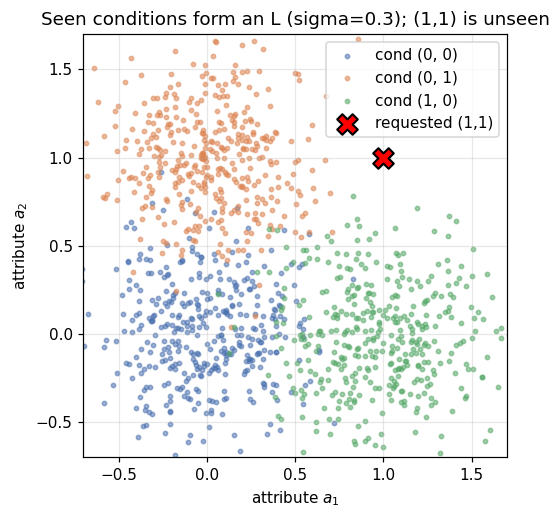

In [3]:
fig, ax = plt.subplots(figsize=(5, 5))
colors = ['#4c72b0', '#dd8452', '#55a868']
for (cond, pts), c in zip(X_by_cond.items(), colors):
    ax.scatter(pts[:, 0], pts[:, 1], s=8, alpha=0.55, color=c,
               label=f'cond {cond}')
ax.scatter(*TARGET, marker='X', s=180, color='red', edgecolor='black',
           linewidth=1.4, zorder=5, label='requested (1,1)')
ax.set_xlabel(r'attribute $a_1$')
ax.set_ylabel(r'attribute $a_2$')
ax.set_xlim(-0.7, 1.7); ax.set_ylim(-0.7, 1.7)
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.legend(loc='upper right', frameon=True)
ax.set_title(f'Seen conditions form an L (sigma={sigma}); (1,1) is unseen')
plt.show()


## 2. Global realism $R(y)$

Fit $(\mu_{\mathrm{real}}, \Sigma_{\mathrm{real}})$ on the pooled real features (Ledoit–Wolf shrinkage for the covariance), evaluate $E_{\mathrm{real}}$ on a grid, and standardize against the real-sample energies to get $R$.

**Larger $R$ = less real**, because $E_{\mathrm{real}}$ is squared Mahalanobis distance.


In [4]:
lw = LedoitWolf().fit(X)
mu_real = lw.location_
prec_real = lw.precision_

def mahal_sq(points, mu, prec):
    d = points - mu
    return np.einsum('ni,ij,nj->n', d, prec, d)

# Energy grid
grid_n = 240
x_g = np.linspace(-0.8, 1.8, grid_n)
y_g = np.linspace(-0.8, 1.8, grid_n)
XX, YY = np.meshgrid(x_g, y_g)
grid_pts = np.stack([XX.ravel(), YY.ravel()], axis=1)

E_grid = mahal_sq(grid_pts, mu_real, prec_real)
E_real_calib = mahal_sq(X, mu_real, prec_real)  # for m_R, s_R
m_R, s_R = E_real_calib.mean(), E_real_calib.std() + 1e-9

R = ((E_grid - m_R) / s_R).reshape(XX.shape)
R_real = (E_real_calib - m_R) / s_R  # R on real samples (mean≈0, std≈1)


## 3. Attribute-wise faithfulness for target $(1, 1)$

For each attribute $k$:

1. Estimate pooled prototypes $\eta_{k,v} = \mathbb E[y \mid a_k = v]$ by averaging real features across the two possible values of $a_k$.
2. Estimate a shared precision matrix $P_k$ from the **pooled within-value** covariance — for each value $v$, center samples at their own $\eta_{k,v}$ and average the resulting covariances. Inverting gives $P_k$.
3. Compute $d_k(y; v)$ on the grid, the margin $M_k(y; 1) = d_k(y; 1) - d_k(y; 0)$, and standardize on the real samples that *do* have $a_k = 1$ (calibrating $m_{k,1}, s_{k,1}$).

$F_k(y; 1)$ is negative where $y$ looks more like attribute $k$ = 1 than 0, and the joint faithfulness is the simple average over $k=1, 2$.


In [5]:
def fit_attribute(X, a_k):
    """Return prototypes {v: eta_{k,v}} and shared precision matrix P_k.
    Mirrors fit_factorized_stats(use_shared_cov=True) from scoring_core.py:
    pooled within-value scatter divided by total_samples, then Ledoit-Wolf
    shrinkage applied on residuals, plus a small 1e-5 ridge before inverse.
    """
    D = X.shape[1]
    values = sorted(np.unique(a_k).tolist())
    protos = {int(v): X[a_k == v].mean(axis=0) for v in values}

    residuals = np.concatenate([X[a_k == v] - protos[int(v)] for v in values], 0)
    pooled_cov = (residuals.T @ residuals) / residuals.shape[0]
    # Ledoit-Wolf shrinkage toward (tr(S)/D) * I, fit on the residuals
    lw_shrink = LedoitWolf().fit(residuals).shrinkage_
    trace_div_d = np.trace(pooled_cov) / D
    pooled_cov = (1 - lw_shrink) * pooled_cov + lw_shrink * trace_div_d * np.eye(D)
    pooled_cov = pooled_cov + 1e-5 * np.eye(D)  # matches scoring_core.py
    P_k = np.linalg.inv(pooled_cov)
    return protos, P_k

protos_1, P1 = fit_attribute(X, a1)
protos_2, P2 = fit_attribute(X, a2)

def d_k(points, eta, P):
    return mahal_sq(points, eta, P)

def margin_grid(target, protos, P):
    """M_k(y; target) over the grid."""
    d_target = d_k(grid_pts, protos[target], P)
    competitors = [v for v in protos if v != target]
    d_others = np.stack([d_k(grid_pts, protos[v], P) for v in competitors], 0)
    return d_target - d_others.min(axis=0)

def margin_real(target, protos, P):
    """M_k(y; target) on every real sample."""
    d_target = d_k(X, protos[target], P)
    competitors = [v for v in protos if v != target]
    d_others = np.stack([d_k(X, protos[v], P) for v in competitors], 0)
    return d_target - d_others.min(axis=0)

# Target (1, 1): t_1 = 1, t_2 = 1
M1_grid = margin_grid(1, protos_1, P1).reshape(XX.shape)
M2_grid = margin_grid(1, protos_2, P2).reshape(XX.shape)

# Calibration mirrors compute_real_calibration_for_factorized_margins:
# for every real sample x_i we evaluate the margin M_k(x_i; t = a_k(x_i))
# (the sample's OWN true value as target), then pool across values to get
# one (m_k, s_k) per attribute. This is what scoring_core.py does.
def calib_pooled(X_real, a_k, protos, P):
    margins = np.empty(len(X_real))
    for v in sorted(protos):
        idx = np.where(a_k == v)[0]
        if idx.size == 0: continue
        margins[idx] = margin_real(v, protos, P)[idx]
    return float(margins.mean()), float(margins.std(ddof=1) + 1e-12), margins

m_1, s_1, M1_real_calib = calib_pooled(X, a1, protos_1, P1)
m_2, s_2, M2_real_calib = calib_pooled(X, a2, protos_2, P2)

F1 = (M1_grid - m_1) / s_1
F2 = (M2_grid - m_2) / s_2
F = 0.5 * (F1 + F2)

# F on every real sample (each evaluated for target (1,1) so the calibration
# threshold tracks 'how the score behaves on real data when the request is
# evaluated against a faithful real sample with a_k=1' — same convention as
# scoring_core.py.compute_real_sample_scores
F1_real_all = (margin_real(1, protos_1, P1) - m_1) / s_1
F2_real_all = (margin_real(1, protos_2, P2) - m_2) / s_2
F_real = 0.5 * (F1_real_all + F2_real_all)


## 4. The two components, real-calibrated

Both heatmaps share the same color convention: **blue = small (good), red = large (bad)**. The white-to-red transition tracks the contour where each score equals its real-sample mean.


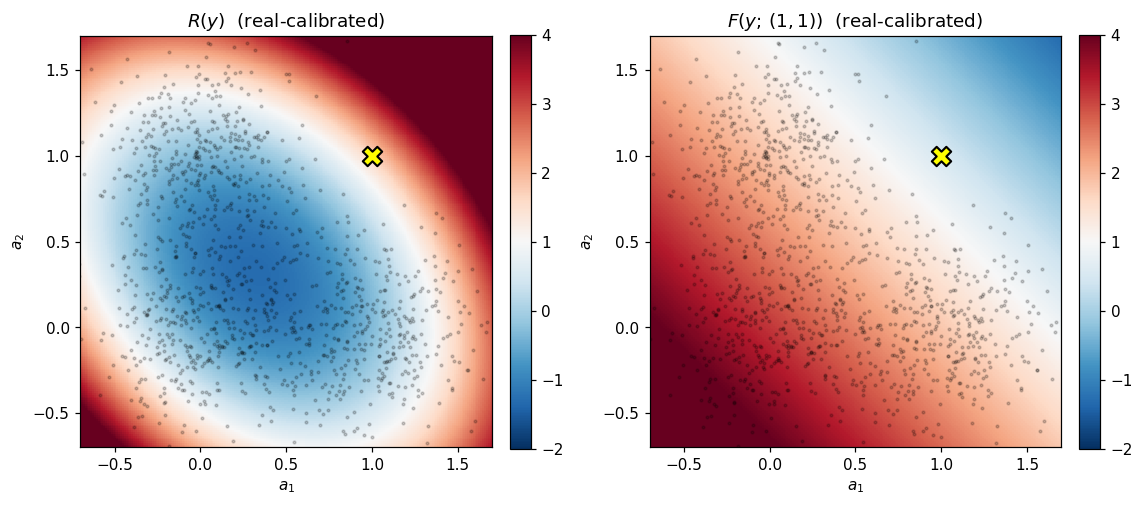

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.8))

im0 = axes[0].pcolormesh(XX, YY, R, cmap='RdBu_r', shading='auto',
                          norm=Normalize(vmin=-2, vmax=4))
axes[0].set_title(r'$R(y)$  (real-calibrated)')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].pcolormesh(XX, YY, F, cmap='RdBu_r', shading='auto',
                          norm=Normalize(vmin=-2, vmax=4))
axes[1].set_title(r'$F(y;\,(1,1))$  (real-calibrated)')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

for ax in axes:
    ax.scatter(X[:, 0], X[:, 1], s=3, color='black', alpha=0.18)
    ax.scatter(*TARGET, marker='X', s=160, color='yellow',
               edgecolor='black', linewidth=1.4, zorder=5)
    ax.set_xlim(-0.7, 1.7); ax.set_ylim(-0.7, 1.7)
    ax.set_aspect('equal')
    ax.set_xlabel(r'$a_1$'); ax.set_ylabel(r'$a_2$')
plt.tight_layout()
plt.show()


## 5. Notes

This is a demonstrational attempt on a toy 2D setting; it is meant to make the two components of the paper's score legible at a glance, not to stand in for a real benchmark.

Two things are visible. $R$ is small (blue) along the L — the seen support — and grows as $y$ moves away from it, including toward the unseen $(1,1)$ corner. $F$ for target $(1,1)$ is small in the upper-right quadrant, because samples there are closer to the seen $a_1{=}1$ and $a_2{=}1$ prototypes than to their respective $0$-competitors. The two heatmaps read the request from genuinely different angles.

On real data the picture is the same in high dimension: $R$ uses the Mahalanobis precision of the pooled real features in DINOv3 / SigLIP space, $F$ uses per-attribute margins under a shared precision matrix $P_k$, and calibration is computed on a held-out real split. See `src/faithful_cond_gen/eval/trust_eval/scoring_core.py` for the full implementation.
